# Customer Segmentation

## Objective

The objective of this phase is to identify distinct customer groups based on behavioral and financial characteristics.

Customer segmentation helps businesses:

- Identify high-risk customers
- Develop targeted retention strategies
- Understand customer value differences
- Improve marketing effectiveness

This analysis uses K-Means Clustering to segment customers into meaningful groups.

In [1]:
%pip install seaborn

In [2]:
# ============================
# Import Libraries
# ============================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
# ============================
# Load Dataset
# ============================

df = pd.read_csv(
    "/drive/customer-churn-analytics-project/data/customer_churn_cleaned.csv"
)

df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## Feature Selection

For clustering, we select variables that reflect customer value, engagement, spending behavior, and churn risk.

Selected variables:

- Tenure Months
- Monthly Charges
- Total Charges
- Churn Score
- CLTV

In [4]:
cluster_features = df[
    [
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "Churn Score",
        "CLTV"
    ]
]

cluster_features.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV
0,2,53.85,108.15,86,3239
1,2,70.70,151.65,67,2701
2,8,99.65,820.50,86,5372
3,28,104.80,3046.05,84,5003
4,49,103.70,5036.30,89,5340


## Feature Scaling

K-Means clustering is distance-based.

To prevent variables with larger numerical ranges from dominating the clustering process, all variables are standardized using StandardScaler.

In [5]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

scaled_features[:5]

array([[-1.23950408, -0.36392329, -0.95964911,  1.2672998 , -0.98318145],
       [-1.23950408,  0.19617818, -0.94045745,  0.38480164, -1.43821508],
       [-0.99504031,  1.15848901, -0.64536922,  1.2672998 ,  0.82088312],
       [-0.18016108,  1.3296773 ,  0.33651554,  1.17440525,  0.50878756],
       [ 0.6754621 ,  1.29311281,  1.2145889 ,  1.40664161,  0.79381792]])

# Determining Optimal Number of Clusters

The Elbow Method is used to identify the most appropriate number of clusters.

The optimal cluster count is typically found where adding additional clusters yields diminishing improvements.

In [6]:
inertia = []

k_range = range(1,11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(
        kmeans.inertia_
    )

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


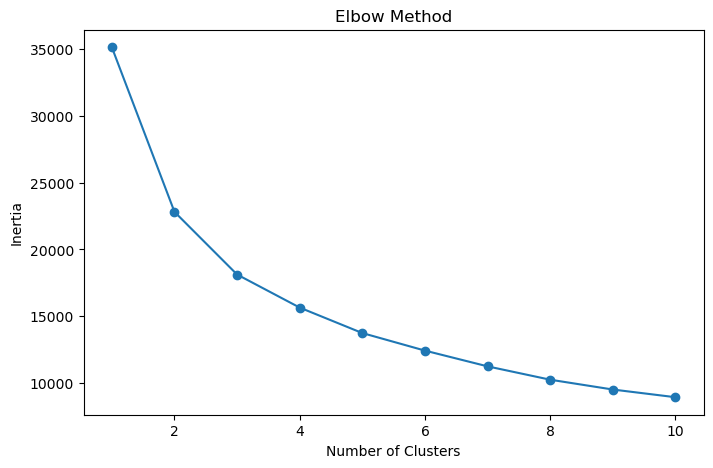

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Inertia"
)

plt.show()

## K-Means Clustering

Based on the Elbow Method, three clusters were selected to segment customers into distinct behavioral groups.

These clusters will later be interpreted as low-, medium-, and high-risk customer segments based on their characteristics.

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df["Cluster"].value_counts()

Cluster
1    2503
0    2462
2    2067
Name: count, dtype: int64

In [9]:
df[[
    "Cluster",
    "Tenure Months",
    "Monthly Charges",
    "Churn Score",
    "CLTV"
]].head()

,Cluster,Tenure Months,Monthly Charges,Churn Score,CLTV
0,1,2,53.85,86,3239
1,1,2,70.70,67,2701
2,1,8,99.65,86,5372
3,1,28,104.80,84,5003
4,2,49,103.70,89,5340


In [10]:
cluster_summary = df.groupby("Cluster")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Score",
    "CLTV",
    "Churn Value"
]].mean().round(2)

cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV,Churn Value
Cluster,,,,,,
0,28.27,36.54,938.04,45.65,4468.59,0.03
1,14.22,71.68,1079.35,75.29,3751.60,0.61
2,59.41,90.12,5343.54,54.20,5108.38,0.13


In [11]:
cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    2462
1    2503
2    2067
Name: count, dtype: int64

In [12]:
df["Risk Cluster"] = df["Cluster"].map({
    0: "Low Risk",
    1: "High Risk",
    2: "Medium Risk"
})

df["Risk Cluster"].value_counts()

Risk Cluster
High Risk      2503
Low Risk       2462
Medium Risk    2067
Name: count, dtype: int64

## Cluster Interpretation

Based on average churn rates and customer characteristics, the clusters were interpreted as follows:

- **Low Risk:** Customers with very low churn probability.
- **Medium Risk:** Relatively stable customers with moderate churn potential.
- **High Risk:** Customers exhibiting the highest churn probability and requiring immediate retention efforts.

In [13]:
risk_summary = df.groupby("Risk Cluster")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Score",
    "CLTV",
    "Churn Value"
]].mean().round(2)

risk_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV,Churn Value
Risk Cluster,,,,,,
High Risk,14.22,71.68,1079.35,75.29,3751.60,0.61
Low Risk,28.27,36.54,938.04,45.65,4468.59,0.03
Medium Risk,59.41,90.12,5343.54,54.20,5108.38,0.13


In [14]:
df.to_csv(
    "/drive/customer-churn-analytics-project/data/customer_churn_segmented.csv",
    index=False
)

print("Segmented dataset saved successfully!")

Segmented dataset saved successfully!


# Segmentation Findings

K-Means clustering successfully identified three distinct customer segments with markedly different churn behaviors.

The High Risk cluster exhibited the highest churn probability and the shortest average tenure, indicating customers most likely to leave the company.

Conversely, the Low Risk cluster demonstrated exceptional retention with minimal churn, while the Medium Risk cluster represented established customers with relatively stable behavior.

These segments provide a valuable foundation for targeted retention campaigns and strategic customer management.